In [1]:
from pathlib import Path
import json
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
json_file = RAW_DATA_DIR / "games.json"

with open(json_file, "r", encoding="utf-8") as f:
    games = json.load(f)

records = []

for appid, game in games.items():
    row = game.copy()
    row["appid"] = int(appid)
    records.append(row)

df = pd.DataFrame(records)

print(f"Loaded {len(df):,} games")

Loaded 135,140 games


In [3]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["release_year"] = (
    df["release_date"]
    .dt.year
    .astype("Int64")
)

for column in ["positive", "negative", "price"]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    ).fillna(0)

df["positive"] = df["positive"].clip(lower=0)
df["negative"] = df["negative"].clip(lower=0)
df["price"] = df["price"].clip(lower=0)

df["total_reviews"] = (
    df["positive"] + df["negative"]
)

REVIEW_MULTIPLIER = 45

df["estimated_revenue"] = (
    df["total_reviews"]
    * REVIEW_MULTIPLIER
    * df["price"]
)

In [4]:
EXCLUDED_TAGS = {
    "early access"
}


def normalize_tags(value):
    if value is None:
        return {}

    if isinstance(value, float) and pd.isna(value):
        return {}

    if isinstance(value, dict):
        raw_tags = value

    elif isinstance(value, str):
        value = value.strip()

        if not value:
            return {}

        try:
            parsed = ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return {}

        if isinstance(parsed, dict):
            raw_tags = parsed
        elif isinstance(parsed, list):
            raw_tags = {str(tag): 1 for tag in parsed}
        else:
            return {}

    elif isinstance(value, list):
        raw_tags = {str(tag): 1 for tag in value}

    else:
        return {}

    cleaned = {}

    for tag, weight in raw_tags.items():
        tag = str(tag).strip()

        if not tag:
            continue

        if tag.casefold() in EXCLUDED_TAGS:
            continue

        try:
            weight = float(weight)
        except (TypeError, ValueError):
            continue

        if weight > 0:
            cleaned[tag] = weight

    return cleaned


df["tags_clean"] = df["tags"].apply(normalize_tags)

df["tag_list"] = df["tags_clean"].apply(
    lambda tags: list(tags.keys())
)

df["is_indie"] = df["tag_list"].apply(
    lambda tags: any(
        tag.casefold() == "indie"
        for tag in tags
    )
)

In [5]:
START_YEAR = 2010
END_YEAR = 2025
MIN_REVIEWS = 20

base_price_sample = df.loc[
    df["release_year"].between(
        START_YEAR,
        END_YEAR,
        inclusive="both"
    )
    & df["is_indie"]
    & df["price"].gt(0)
].copy()

indie_price_sample = base_price_sample.loc[
    base_price_sample["total_reviews"] >= MIN_REVIEWS
].copy()

middle_price_sample = indie_price_sample.loc[
    indie_price_sample["estimated_revenue"].between(
        150_000,
        800_000,
        inclusive="both"
    )
].copy()

print(f"Paid Indie games before review filter: {len(base_price_sample):,}")
print(f"Paid Indie games with ≥{MIN_REVIEWS} reviews: {len(indie_price_sample):,}")
print(f"Games in $150K–$800K band: {len(middle_price_sample):,}")

Paid Indie games before review filter: 43,374
Paid Indie games with ≥20 reviews: 22,446
Games in $150K–$800K band: 2,205


In [6]:
review_filter_effect = (
    base_price_sample
    .groupby("release_year")
    .agg(
        all_paid_indies=("appid", "nunique"),
        games_with_20_reviews=(
            "total_reviews",
            lambda values: values.ge(MIN_REVIEWS).sum()
        )
    )
    .reset_index()
)

review_filter_effect["retained_share"] = (
    100
    * review_filter_effect["games_with_20_reviews"]
    / review_filter_effect["all_paid_indies"]
)

display(
    review_filter_effect.style.format({
        "all_paid_indies": "{:,.0f}",
        "games_with_20_reviews": "{:,.0f}",
        "retained_share": "{:.1f}%"
    }).hide(axis="index")
)

release_year,all_paid_indies,games_with_20_reviews,retained_share
2010,71,70,98.6%
2011,98,95,96.9%
2012,155,154,99.4%
2013,242,242,100.0%
2014,806,792,98.3%
2015,"1,650","1,494",90.5%
2016,"2,566","2,056",80.1%
2017,"3,664","2,371",64.7%
2018,"4,742","2,641",55.7%
2019,"4,266","2,088",48.9%


In [7]:
indie_price_by_year = (
    indie_price_sample
    .groupby("release_year")
    .agg(
        games=("appid", "nunique"),
        q25_price=("price", lambda values: values.quantile(0.25)),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        q75_price=("price", lambda values: values.quantile(0.75))
    )
    .reset_index()
)

indie_price_by_year

,release_year,games,q25_price,median_price,mean_price,q75_price
0,2010,70,1.24,2.49,3.134143,4.990
1,2011,95,1.99,2.99,4.354421,4.990
2,2012,154,1.99,2.99,4.260909,4.990
3,2013,242,1.49,2.49,3.982975,4.990
4,2014,792,1.39,2.99,4.236061,4.990
5,2015,1494,0.99,2.99,4.217450,4.990
6,2016,2056,0.99,2.49,4.046863,4.990
7,2017,2371,0.99,2.39,4.188621,4.990
8,2018,2641,0.99,2.09,4.438580,4.990
9,2019,2088,0.99,2.99,5.001341,6.415


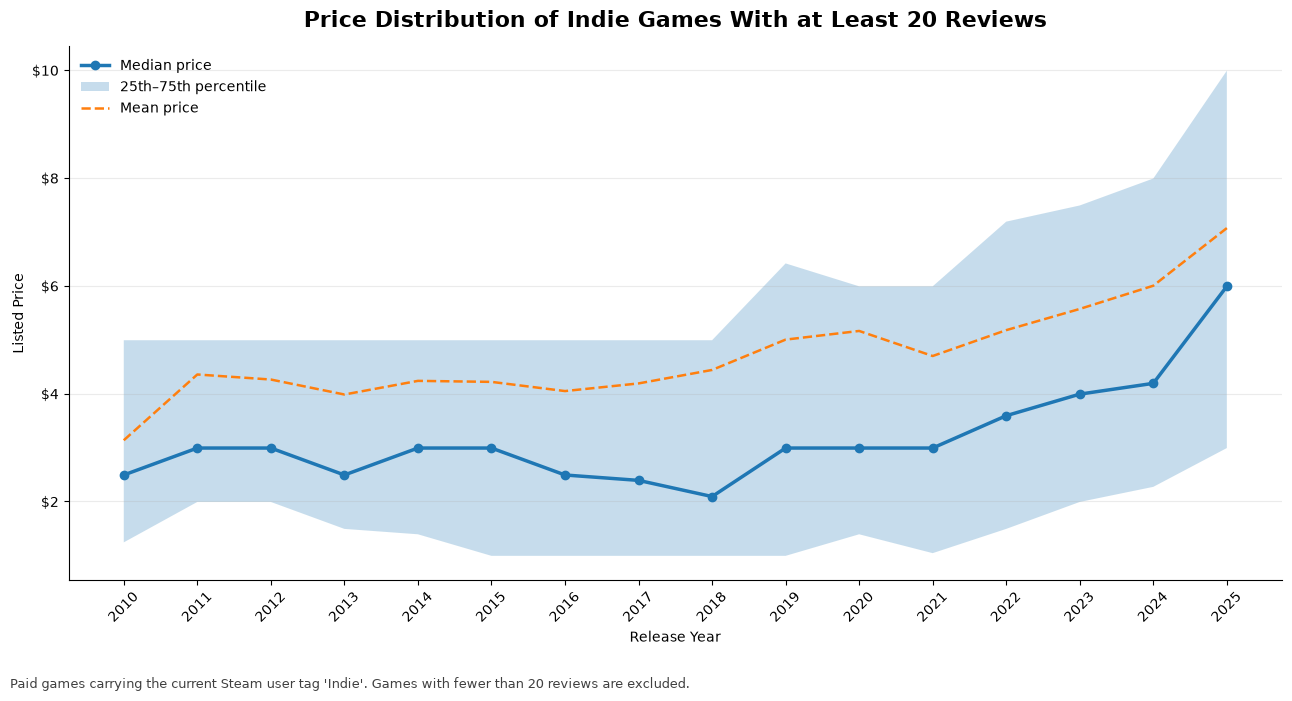

In [8]:
plot_data = indie_price_by_year.copy()

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(
    plot_data["release_year"],
    plot_data["median_price"],
    marker="o",
    linewidth=2.5,
    label="Median price"
)

ax.fill_between(
    plot_data["release_year"],
    plot_data["q25_price"],
    plot_data["q75_price"],
    alpha=0.25,
    label="25th–75th percentile"
)

ax.plot(
    plot_data["release_year"],
    plot_data["mean_price"],
    linestyle="--",
    linewidth=1.8,
    label="Mean price"
)

ax.set_title(
    f"Price Distribution of Indie Games With at Least {MIN_REVIEWS} Reviews",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Listed Price")

ax.set_xticks(
    plot_data["release_year"]
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value:.0f}"
    )
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

fig.text(
    0.01,
    0.01,
    (
        "Paid games carrying the current Steam user tag 'Indie'. "
        f"Games with fewer than {MIN_REVIEWS} reviews are excluded."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

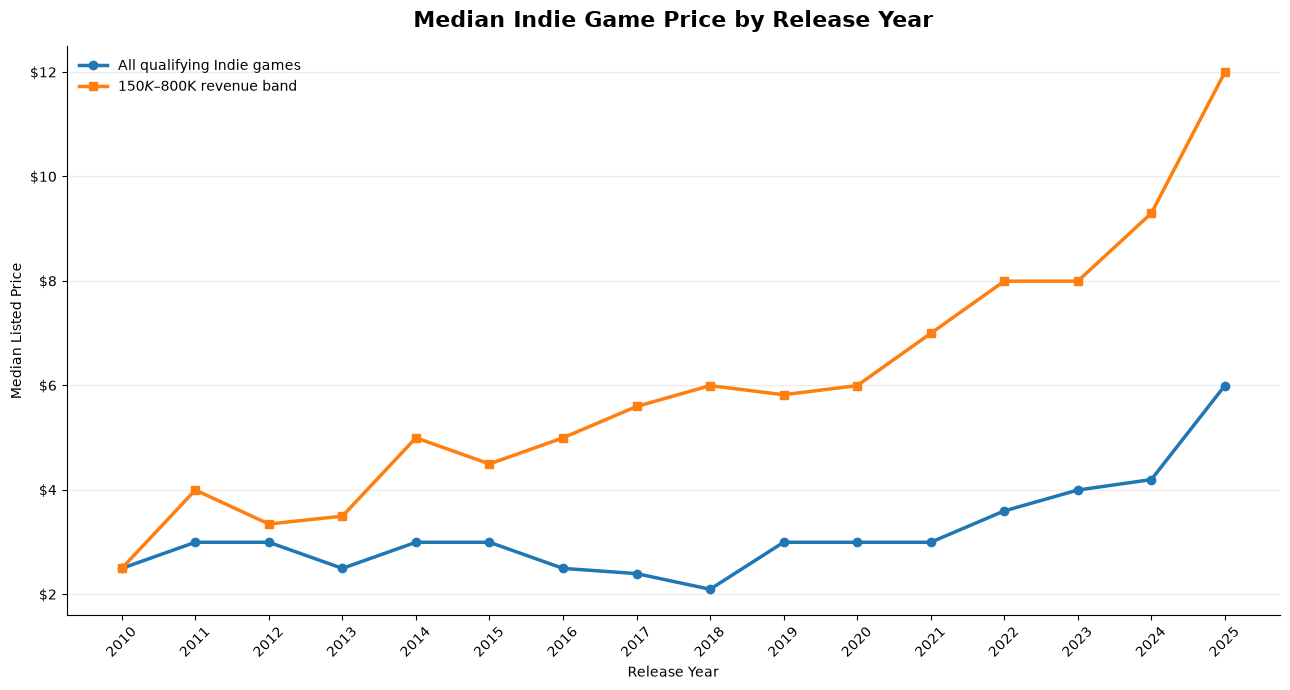

In [9]:
middle_price_by_year = (
    middle_price_sample
    .groupby("release_year")
    .agg(
        games=("appid", "nunique"),
        q25_price=("price", lambda values: values.quantile(0.25)),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        q75_price=("price", lambda values: values.quantile(0.75))
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(
    indie_price_by_year["release_year"],
    indie_price_by_year["median_price"],
    marker="o",
    linewidth=2.5,
    label="All qualifying Indie games"
)

ax.plot(
    middle_price_by_year["release_year"],
    middle_price_by_year["median_price"],
    marker="s",
    linewidth=2.5,
    label="$150K–$800K revenue band"
)

ax.set_title(
    "Median Indie Game Price by Release Year",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Median Listed Price")

ax.set_xticks(range(START_YEAR, END_YEAR + 1))
ax.tick_params(axis="x", rotation=45)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value:.0f}"
    )
)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

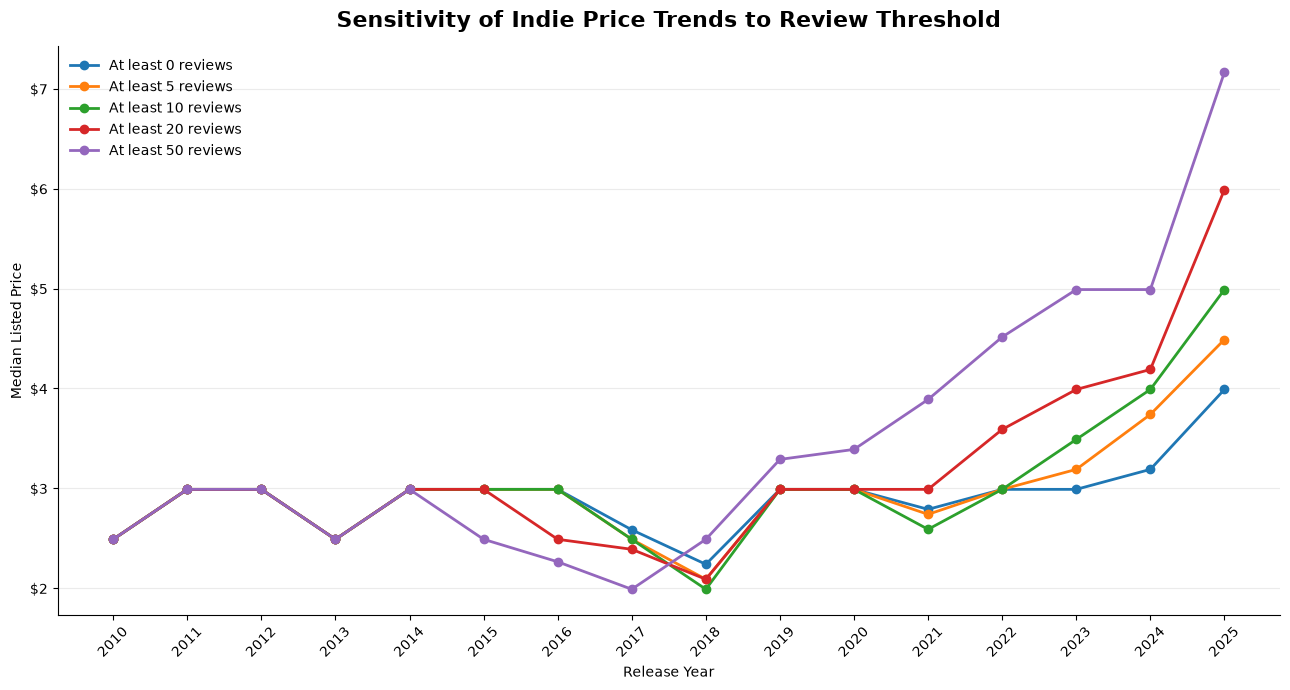

In [10]:
REVIEW_THRESHOLDS = [0, 5, 10, 20, 50]

threshold_price_rows = []

for threshold in REVIEW_THRESHOLDS:

    threshold_sample = base_price_sample.loc[
        base_price_sample["total_reviews"] >= threshold
    ]

    yearly = (
        threshold_sample
        .groupby("release_year")
        .agg(
            games=("appid", "nunique"),
            median_price=("price", "median")
        )
        .reset_index()
    )

    yearly["review_threshold"] = threshold

    threshold_price_rows.append(yearly)

threshold_price_comparison = pd.concat(
    threshold_price_rows,
    ignore_index=True
)

fig, ax = plt.subplots(figsize=(13, 7))

for threshold, group in threshold_price_comparison.groupby(
    "review_threshold"
):
    ax.plot(
        group["release_year"],
        group["median_price"],
        marker="o",
        linewidth=2,
        label=f"At least {threshold} reviews"
    )

ax.set_title(
    "Sensitivity of Indie Price Trends to Review Threshold",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Median Listed Price")

ax.set_xticks(range(START_YEAR, END_YEAR + 1))
ax.tick_params(axis="x", rotation=45)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value:.0f}"
    )
)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [11]:
PRICE_BINS = [
    0,
    3,
    5,
    8,
    10,
    15,
    20,
    30,
    40,
    60,
    np.inf
]

PRICE_LABELS = [
    "$0.01–2.99",
    "$3–4.99",
    "$5–7.99",
    "$8–9.99",
    "$10–14.99",
    "$15–19.99",
    "$20–29.99",
    "$30–39.99",
    "$40–59.99",
    "$60+"
]

# Ordered category ensures charts use the intended price order
price_category_type = pd.CategoricalDtype(
    categories=PRICE_LABELS,
    ordered=True
)

indie_price_sample["price_bucket"] = pd.cut(
    indie_price_sample["price"],
    bins=PRICE_BINS,
    labels=PRICE_LABELS,
    right=False,
    include_lowest=True
).astype(price_category_type)

middle_price_sample["price_bucket"] = pd.cut(
    middle_price_sample["price"],
    bins=PRICE_BINS,
    labels=PRICE_LABELS,
    right=False,
    include_lowest=True
).astype(price_category_type)

print(indie_price_sample["price_bucket"].value_counts().sort_index())

price_bucket
$0.01–2.99    11660
$3–4.99        4219
$5–7.99        2481
$8–9.99        1713
$10–14.99      1529
$15–19.99       598
$20–29.99       184
$30–39.99        28
$40–59.99        23
$60+             11
Name: count, dtype: int64


In [12]:
def summarize_price_performance(data):
    summary = (
        data
        .dropna(subset=["price_bucket"])
        .groupby(
            "price_bucket",
            observed=False
        )
        .agg(
            games=("appid", "nunique"),
            median_price=("price", "median"),
            median_revenue=("estimated_revenue", "median"),
            mean_revenue=("estimated_revenue", "mean"),
            total_revenue=("estimated_revenue", "sum"),
            median_reviews=("total_reviews", "median"),
            success_150k=(
                "estimated_revenue",
                lambda values: 100 * values.ge(150_000).mean()
            ),
            success_500k=(
                "estimated_revenue",
                lambda values: 100 * values.ge(500_000).mean()
            ),
            success_1m=(
                "estimated_revenue",
                lambda values: 100 * values.ge(1_000_000).mean()
            )
        )
        .reset_index()
    )

    return summary


all_indie_price_summary = summarize_price_performance(
    indie_price_sample
)

middle_price_summary = summarize_price_performance(
    middle_price_sample
)

In [13]:
display(
    all_indie_price_summary.style.format({
        "games": "{:,.0f}",
        "median_price": "${:,.2f}",
        "median_revenue": "${:,.0f}",
        "mean_revenue": "${:,.0f}",
        "total_revenue": "${:,.0f}",
        "median_reviews": "{:,.0f}",
        "success_150k": "{:.1f}%",
        "success_500k": "{:.1f}%",
        "success_1m": "{:.1f}%"
    }).hide(axis="index")
)

price_bucket,games,median_price,median_revenue,mean_revenue,total_revenue,median_reviews,success_150k,success_500k,success_1m
$0.01–2.99,"11,660",$1.24,"$4,648","$71,652","$835,466,183",78,5.5%,1.9%,1.1%
$3–4.99,"4,219",$4.49,"$18,862","$500,992","$2,113,685,675",97,16.8%,8.2%,5.2%
$5–7.99,"2,481",$6.79,"$33,424","$736,656","$1,827,644,673",110,23.6%,11.9%,8.1%
$8–9.99,"1,713",$9.99,"$45,405","$1,244,476","$2,131,786,545",105,27.9%,13.8%,8.1%
$10–14.99,"1,529",$12.99,"$86,248","$2,129,145","$3,255,462,706",147,39.5%,22.4%,15.0%
$15–19.99,598,$19.99,"$151,124","$4,165,209","$2,490,795,148",186,50.3%,30.8%,23.1%
$20–29.99,184,$24.99,"$478,400","$12,020,963","$2,211,857,271",409,66.3%,49.5%,38.0%
$30–39.99,28,$34.99,"$638,378","$21,389,852","$598,915,858",382,75.0%,53.6%,46.4%
$40–59.99,23,$54.99,"$247,455","$3,314,350","$76,230,040",100,73.9%,13.0%,13.0%
$60+,11,$199.99,"$332,983","$566,216","$6,228,378",37,100.0%,18.2%,9.1%


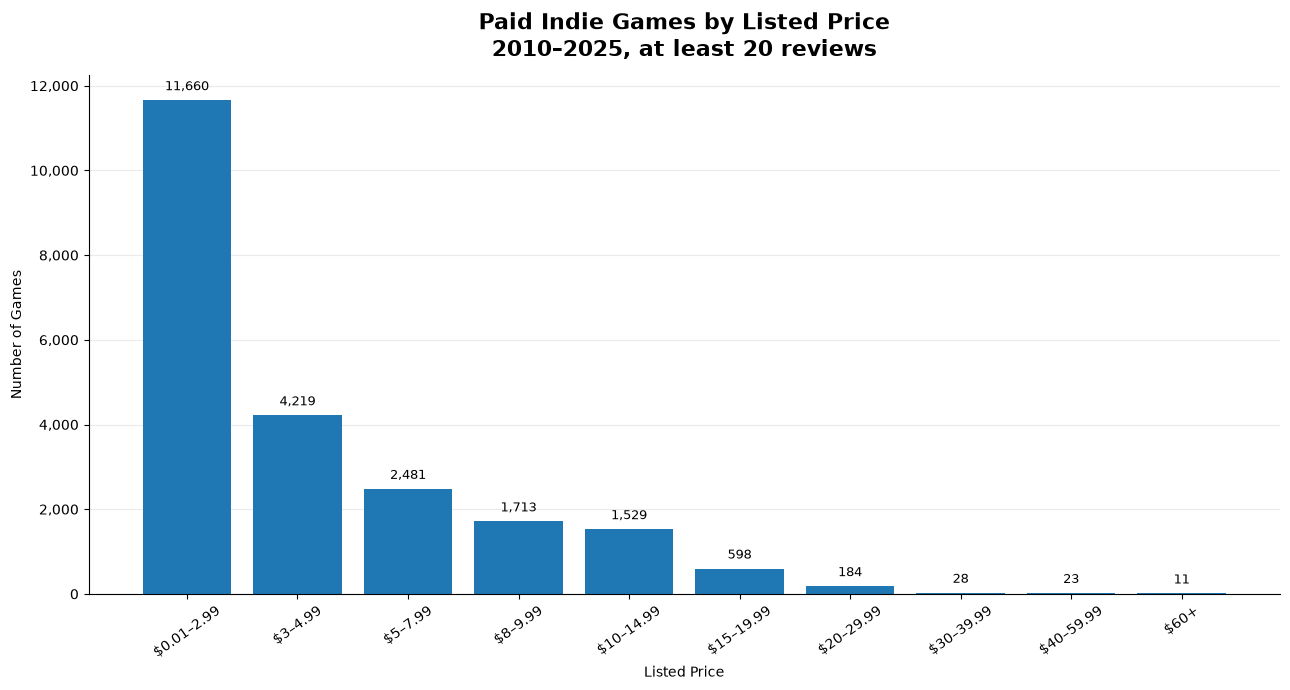

In [14]:
plot_data = all_indie_price_summary.loc[
    all_indie_price_summary["games"] > 0
].copy()

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(
    plot_data["price_bucket"].astype(str),
    plot_data["games"]
)

for bar, games_count in zip(
    bars,
    plot_data["games"]
):
    ax.annotate(
        f"{int(games_count):,}",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    (
        f"Paid Indie Games by Listed Price\n"
        f"{START_YEAR}–{END_YEAR}, at least {MIN_REVIEWS} reviews"
    ),
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Listed Price")
ax.set_ylabel("Number of Games")

ax.tick_params(axis="x", rotation=35)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.0f}")
)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

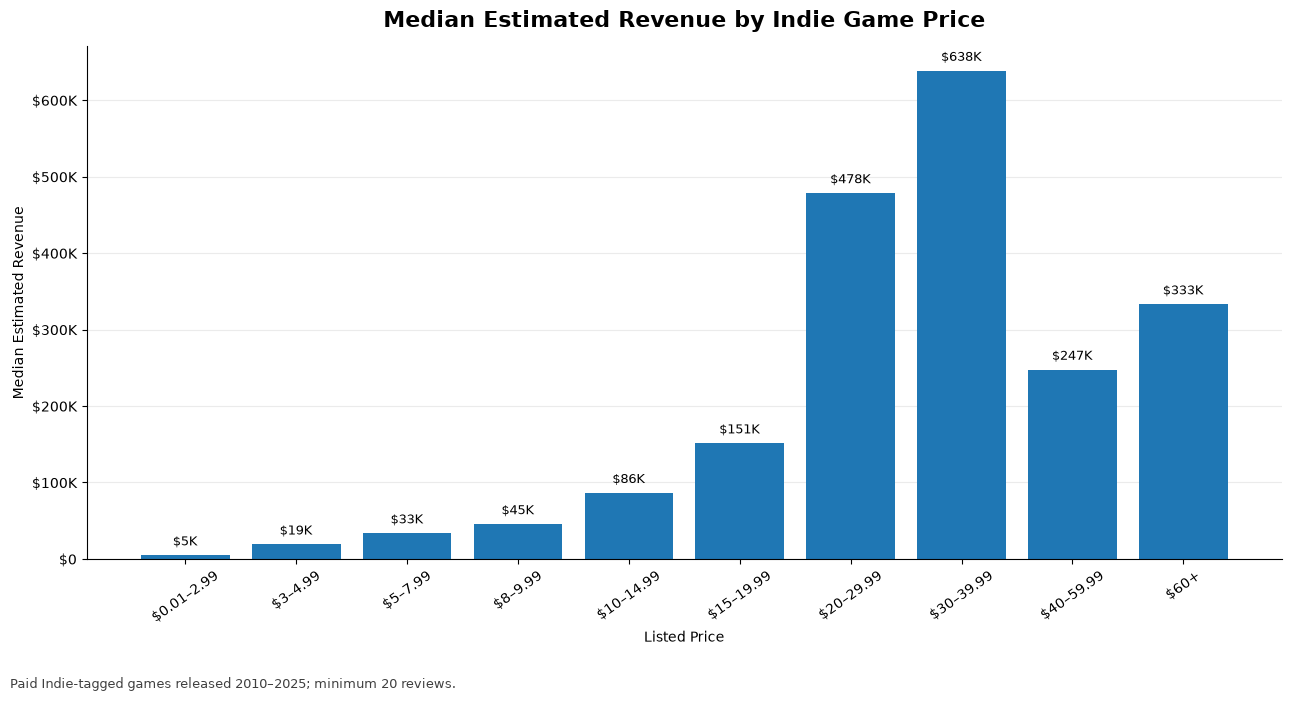

In [15]:
plot_data = all_indie_price_summary.loc[
    all_indie_price_summary["games"] > 0
].copy()

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(
    plot_data["price_bucket"].astype(str),
    plot_data["median_revenue"]
)

def format_revenue(value, position=None):
    if value >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"
    if value >= 1_000:
        return f"${value / 1_000:.0f}K"
    return f"${value:,.0f}"

for bar, revenue in zip(
    bars,
    plot_data["median_revenue"]
):
    ax.annotate(
        format_revenue(revenue),
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    "Median Estimated Revenue by Indie Game Price",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Listed Price")
ax.set_ylabel("Median Estimated Revenue")

ax.tick_params(axis="x", rotation=35)
ax.yaxis.set_major_formatter(
    FuncFormatter(format_revenue)
)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        f"Paid Indie-tagged games released {START_YEAR}–{END_YEAR}; "
        f"minimum {MIN_REVIEWS} reviews."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

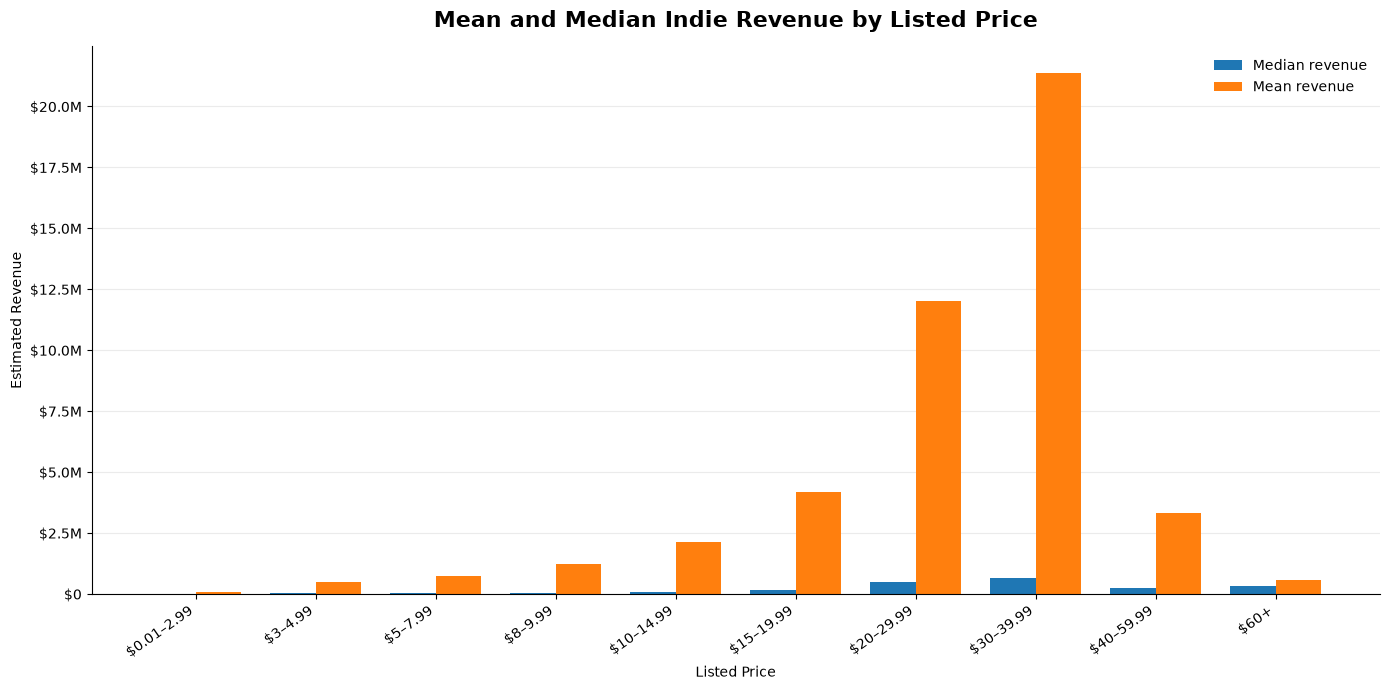

In [16]:
plot_data = all_indie_price_summary.loc[
    all_indie_price_summary["games"] > 0
].copy()

x = np.arange(len(plot_data))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    x - bar_width / 2,
    plot_data["median_revenue"],
    width=bar_width,
    label="Median revenue"
)

ax.bar(
    x + bar_width / 2,
    plot_data["mean_revenue"],
    width=bar_width,
    label="Mean revenue"
)

ax.set_title(
    "Mean and Median Indie Revenue by Listed Price",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Listed Price")
ax.set_ylabel("Estimated Revenue")

ax.set_xticks(x)
ax.set_xticklabels(
    plot_data["price_bucket"].astype(str),
    rotation=35,
    ha="right"
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_revenue)
)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

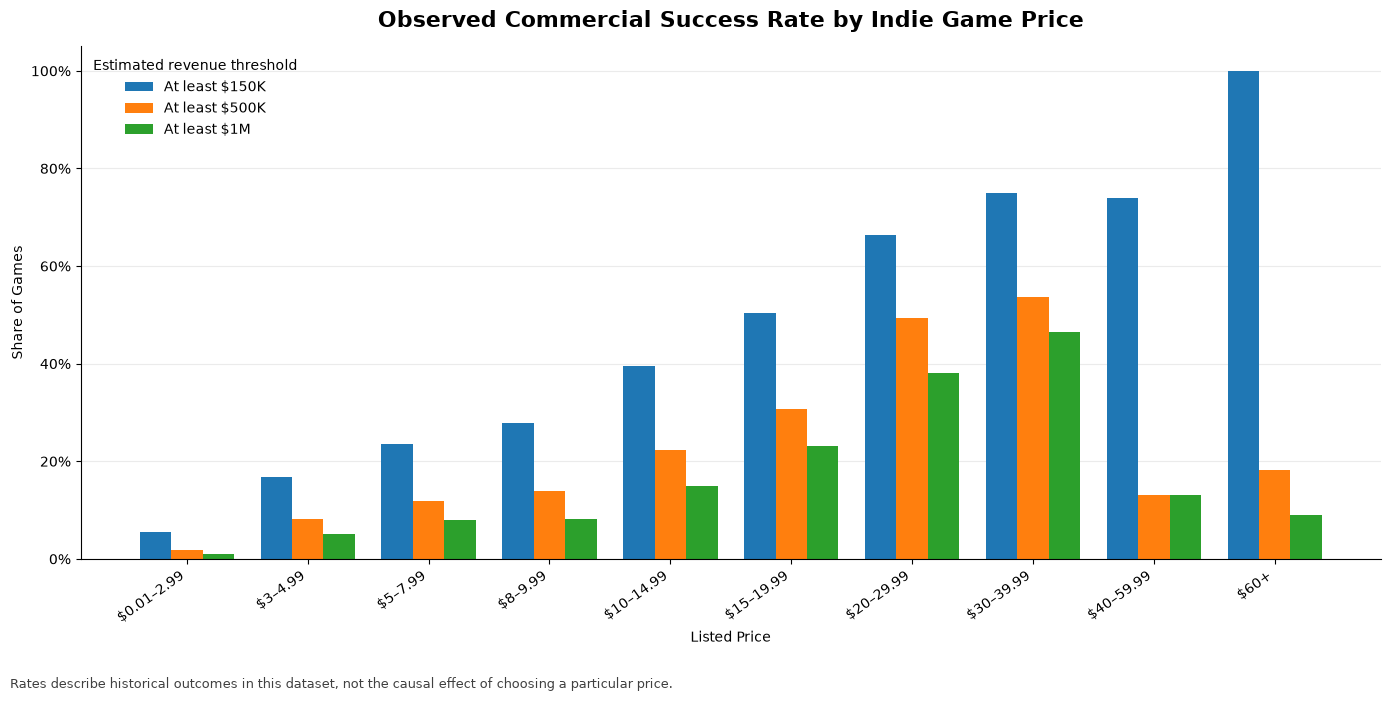

In [17]:
plot_data = all_indie_price_summary.loc[
    all_indie_price_summary["games"] > 0
].copy()

x = np.arange(len(plot_data))
bar_width = 0.26

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    x - bar_width,
    plot_data["success_150k"],
    width=bar_width,
    label="At least $150K"
)

ax.bar(
    x,
    plot_data["success_500k"],
    width=bar_width,
    label="At least $500K"
)

ax.bar(
    x + bar_width,
    plot_data["success_1m"],
    width=bar_width,
    label="At least $1M"
)

ax.set_title(
    "Observed Commercial Success Rate by Indie Game Price",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Listed Price")
ax.set_ylabel("Share of Games")

ax.set_xticks(x)
ax.set_xticklabels(
    plot_data["price_bucket"].astype(str),
    rotation=35,
    ha="right"
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:.0f}%")
)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.legend(
    title="Estimated revenue threshold",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Rates describe historical outcomes in this dataset, not the causal "
        "effect of choosing a particular price."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [18]:
price_comparison = (
    all_indie_price_summary[
        [
            "price_bucket",
            "games",
            "median_revenue"
        ]
    ]
    .rename(columns={
        "games": "all_indie_games",
        "median_revenue": "all_indie_median_revenue"
    })
    .merge(
        middle_price_summary[
            [
                "price_bucket",
                "games",
                "median_revenue"
            ]
        ].rename(columns={
            "games": "middle_band_games",
            "median_revenue": "middle_band_median_revenue"
        }),
        on="price_bucket",
        how="outer"
    )
    .fillna(0)
)

price_comparison

,price_bucket,all_indie_games,all_indie_median_revenue,middle_band_games,middle_band_median_revenue
0,$0.01–2.99,11660,4648.500,490,261152.550
1,$3–4.99,4219,18862.200,459,304938.900
2,$5–7.99,2481,33424.200,367,265480.200
3,$8–9.99,1713,45404.550,311,307492.200
4,$10–14.99,1529,86248.350,340,297476.550
5,$15–19.99,598,151124.400,155,342728.550
6,$20–29.99,184,478399.950,51,381598.200
7,$30–39.99,28,638377.875,8,234724.725
8,$40–59.99,23,247455.000,14,247455.000
9,$60+,11,332983.350,10,319484.025


In [21]:
plot_data = price_comparison.loc[
    (price_comparison["all_indie_games"] > 0)
    | (price_comparison["middle_band_games"] > 0)
].copy()

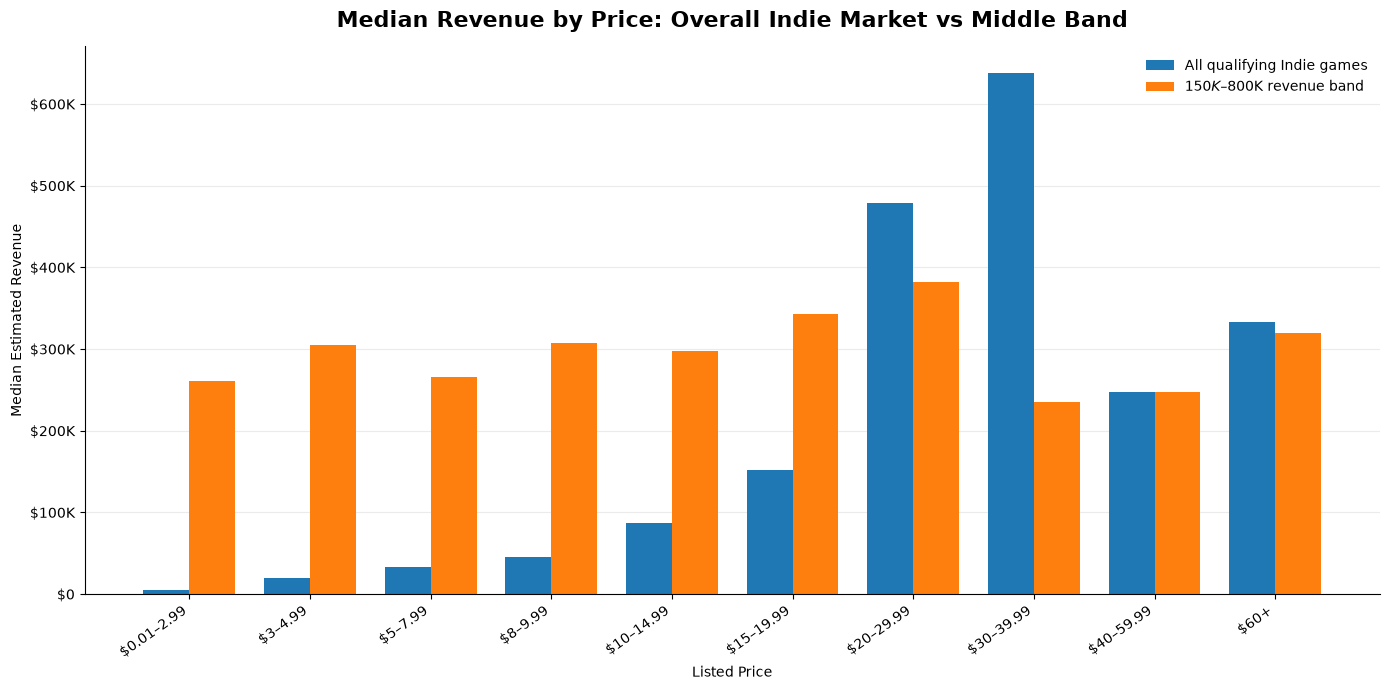

In [22]:
x = np.arange(len(plot_data))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    x - bar_width / 2,
    plot_data["all_indie_median_revenue"],
    width=bar_width,
    label="All qualifying Indie games"
)

ax.bar(
    x + bar_width / 2,
    plot_data["middle_band_median_revenue"],
    width=bar_width,
    label="$150K–$800K revenue band"
)

ax.set_title(
    "Median Revenue by Price: Overall Indie Market vs Middle Band",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Listed Price")
ax.set_ylabel("Median Estimated Revenue")

ax.set_xticks(x)
ax.set_xticklabels(
    plot_data["price_bucket"].astype(str),
    rotation=35,
    ha="right"
)

ax.yaxis.set_major_formatter(
    FuncFormatter(format_revenue)
)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

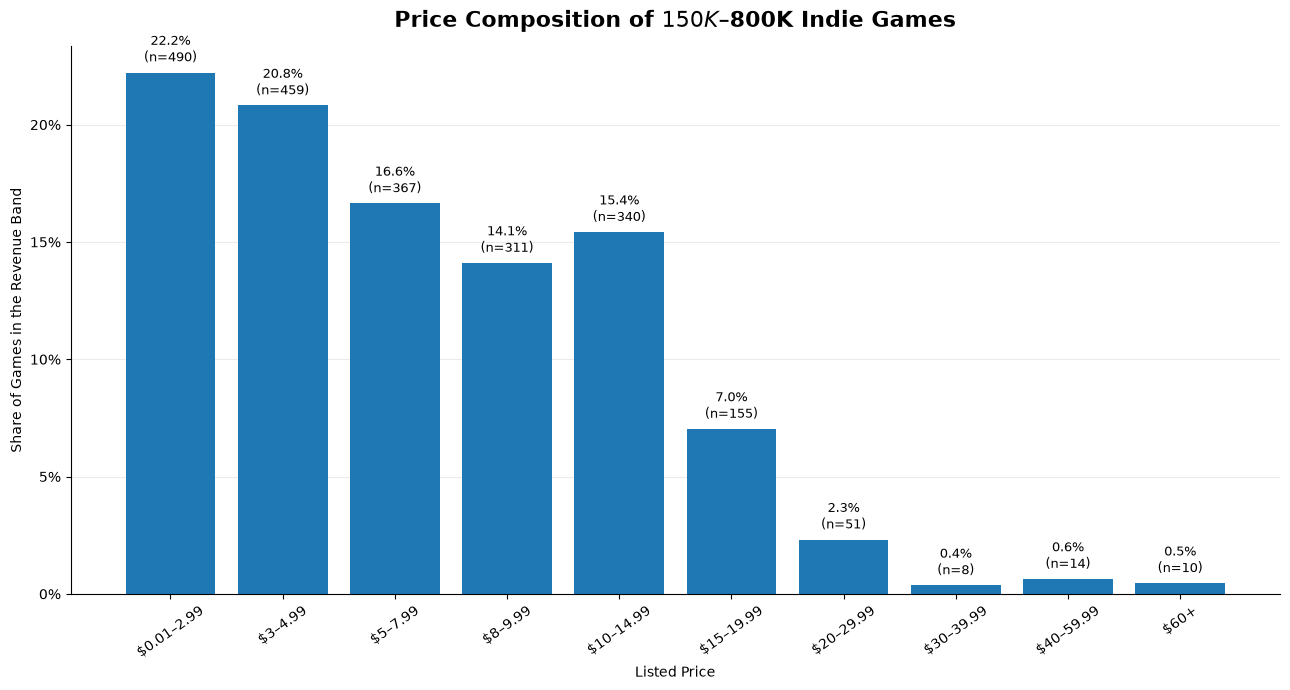

In [23]:
middle_bucket_distribution = (
    middle_price_sample
    .groupby(
        "price_bucket",
        observed=False
    )
    .agg(
        games=("appid", "nunique")
    )
    .reset_index()
)

middle_bucket_distribution["share_of_middle_band"] = (
    100
    * middle_bucket_distribution["games"]
    / middle_bucket_distribution["games"].sum()
)

plot_data = middle_bucket_distribution.loc[
    middle_bucket_distribution["games"] > 0
].copy()

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(
    plot_data["price_bucket"].astype(str),
    plot_data["share_of_middle_band"]
)

for bar, share, count in zip(
    bars,
    plot_data["share_of_middle_band"],
    plot_data["games"]
):
    ax.annotate(
        f"{share:.1f}%\n(n={int(count):,})",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    "Price Composition of $150K–$800K Indie Games",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Listed Price")
ax.set_ylabel("Share of Games in the Revenue Band")

ax.tick_params(axis="x", rotation=35)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:.0f}%")
)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

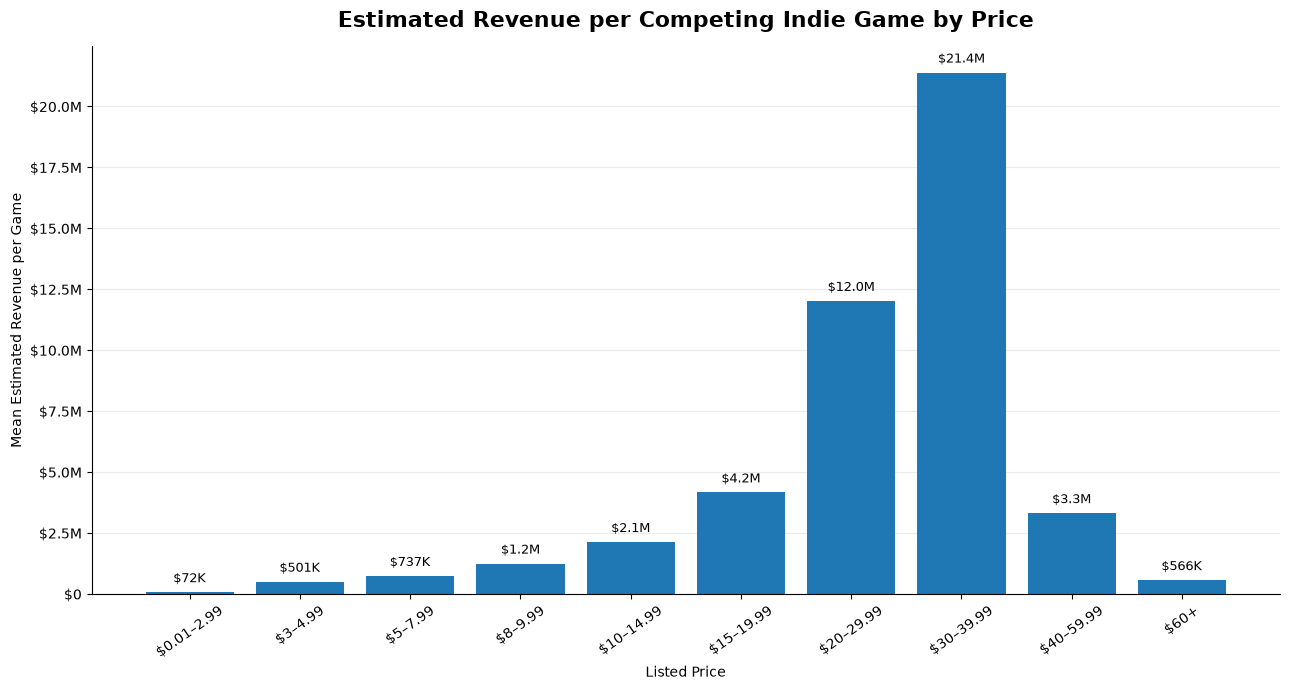

In [24]:
price_attractiveness = (
    indie_price_sample
    .dropna(subset=["price_bucket"])
    .groupby(
        "price_bucket",
        observed=False
    )
    .agg(
        games=("appid", "nunique"),
        total_revenue=("estimated_revenue", "sum")
    )
    .reset_index()
)

price_attractiveness["revenue_per_game"] = (
    price_attractiveness["total_revenue"]
    / price_attractiveness["games"]
)

plot_data = price_attractiveness.loc[
    price_attractiveness["games"] > 0
].copy()

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(
    plot_data["price_bucket"].astype(str),
    plot_data["revenue_per_game"]
)

for bar, value in zip(
    bars,
    plot_data["revenue_per_game"]
):
    ax.annotate(
        format_revenue(value),
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    "Estimated Revenue per Competing Indie Game by Price",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Listed Price")
ax.set_ylabel("Mean Estimated Revenue per Game")

ax.tick_params(axis="x", rotation=35)
ax.yaxis.set_major_formatter(
    FuncFormatter(format_revenue)
)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [25]:
price_year_summary = (
    indie_price_sample
    .dropna(subset=["price_bucket"])
    .groupby(
        ["release_year", "price_bucket"],
        observed=False
    )
    .agg(
        games=("appid", "nunique"),
        median_revenue=("estimated_revenue", "median"),
        mean_revenue=("estimated_revenue", "mean"),
        success_150k=(
            "estimated_revenue",
            lambda values: 100 * values.ge(150_000).mean()
        ),
        success_500k=(
            "estimated_revenue",
            lambda values: 100 * values.ge(500_000).mean()
        ),
        success_1m=(
            "estimated_revenue",
            lambda values: 100 * values.ge(1_000_000).mean()
        )
    )
    .reset_index()
)

price_year_summary.head()

,release_year,price_bucket,games,median_revenue,mean_revenue,success_150k,success_500k,success_1m
0,2010,$0.01–2.99,46,40319.775,2.612510e+05,17.391304,8.695652,4.347826
1,2010,$3–4.99,17,37050.750,2.331747e+06,23.529412,11.764706,11.764706
2,2010,$5–7.99,3,36928.350,5.791140e+04,0.000000,0.000000,0.000000
3,2010,$8–9.99,4,59340.600,8.901090e+04,25.000000,0.000000,0.000000
4,2010,$10–14.99,0,NaN,NaN,NaN,NaN,NaN


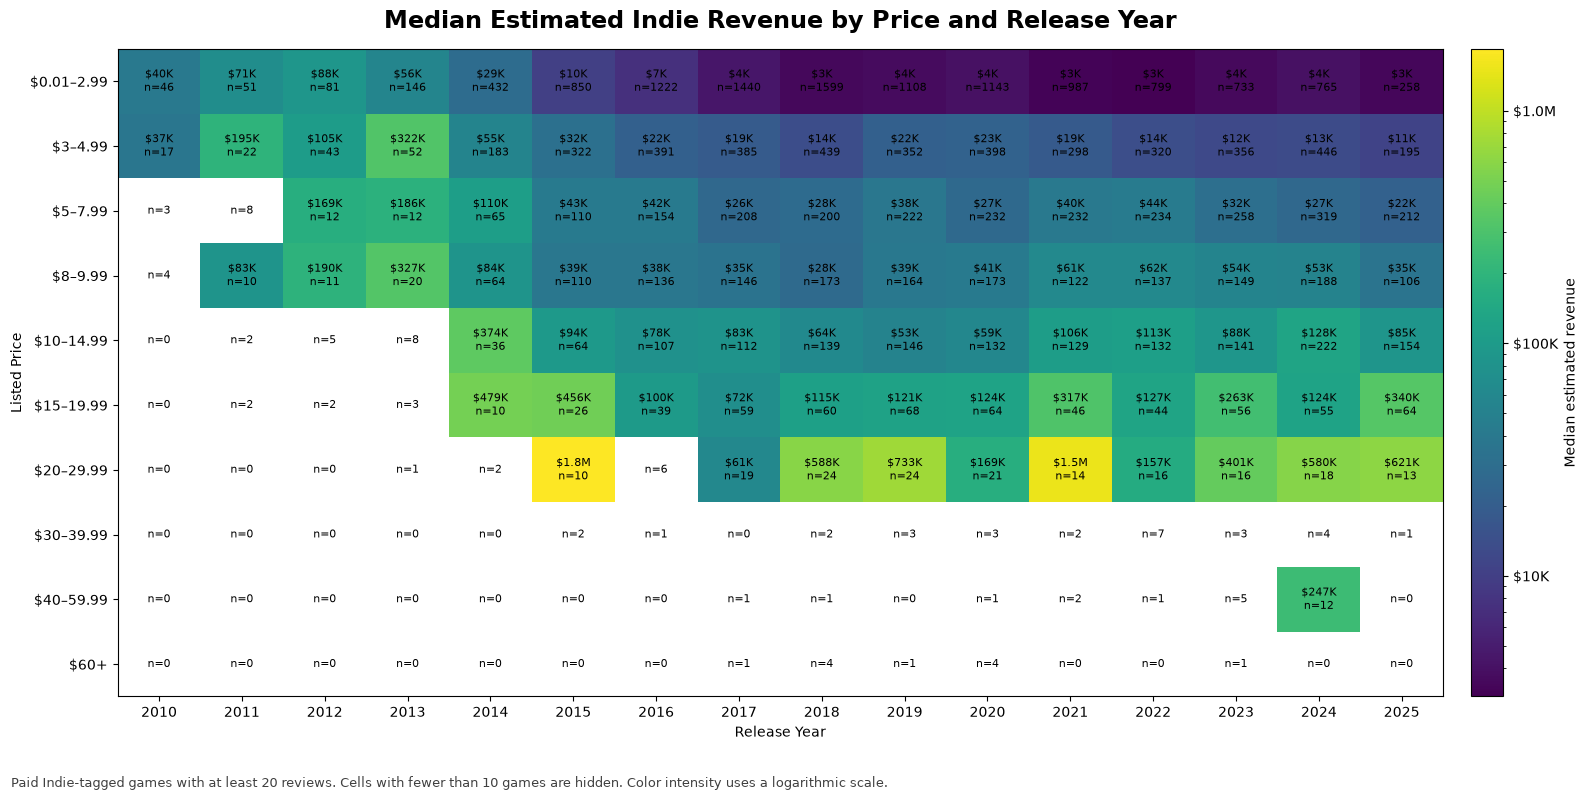

In [26]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.ticker import FuncFormatter

MIN_GAMES_PER_CELL = 10

median_revenue_heatmap = (
    price_year_summary
    .pivot(
        index="price_bucket",
        columns="release_year",
        values="median_revenue"
    )
    .reindex(PRICE_LABELS)
)

games_heatmap = (
    price_year_summary
    .pivot(
        index="price_bucket",
        columns="release_year",
        values="games"
    )
    .reindex(PRICE_LABELS)
)

# Hide cells with very small samples
median_revenue_heatmap = median_revenue_heatmap.mask(
    games_heatmap < MIN_GAMES_PER_CELL
)

valid_values = median_revenue_heatmap.to_numpy()
valid_values = valid_values[
    np.isfinite(valid_values) & (valid_values > 0)
]

fig, ax = plt.subplots(figsize=(16, 8))

if len(valid_values) > 0:
    color_norm = colors.LogNorm(
        vmin=valid_values.min(),
        vmax=valid_values.max()
    )
else:
    color_norm = colors.Normalize(vmin=0, vmax=1)

image = ax.imshow(
    median_revenue_heatmap.values,
    aspect="auto",
    cmap="viridis",
    norm=color_norm
)

ax.set_xticks(
    range(len(median_revenue_heatmap.columns))
)

ax.set_xticklabels(
    median_revenue_heatmap.columns
)

ax.set_yticks(
    range(len(median_revenue_heatmap.index))
)

ax.set_yticklabels(
    median_revenue_heatmap.index
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Listed Price")

ax.set_title(
    "Median Estimated Indie Revenue by Price and Release Year",
    fontsize=17,
    fontweight="bold",
    pad=15
)

def compact_dollars(value):
    if value >= 1_000_000:
        return f"${value / 1_000_000:.1f}M"
    if value >= 1_000:
        return f"${value / 1_000:.0f}K"
    return f"${value:,.0f}"

for row in range(
    len(median_revenue_heatmap.index)
):
    for column in range(
        len(median_revenue_heatmap.columns)
    ):
        revenue = median_revenue_heatmap.iloc[
            row,
            column
        ]

        games_count = games_heatmap.iloc[
            row,
            column
        ]

        if pd.isna(revenue):
            label = (
                "—"
                if pd.isna(games_count)
                else f"n={int(games_count)}"
            )
        else:
            label = (
                f"{compact_dollars(revenue)}\n"
                f"n={int(games_count)}"
            )

        ax.text(
            column,
            row,
            label,
            ha="center",
            va="center",
            fontsize=8
        )

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.025,
    pad=0.02
)

colorbar.set_label(
    "Median estimated revenue"
)

colorbar.ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        compact_dollars(value)
    )
)

fig.text(
    0.01,
    0.01,
    (
        f"Paid Indie-tagged games with at least {MIN_REVIEWS} reviews. "
        f"Cells with fewer than {MIN_GAMES_PER_CELL} games are hidden. "
        "Color intensity uses a logarithmic scale."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

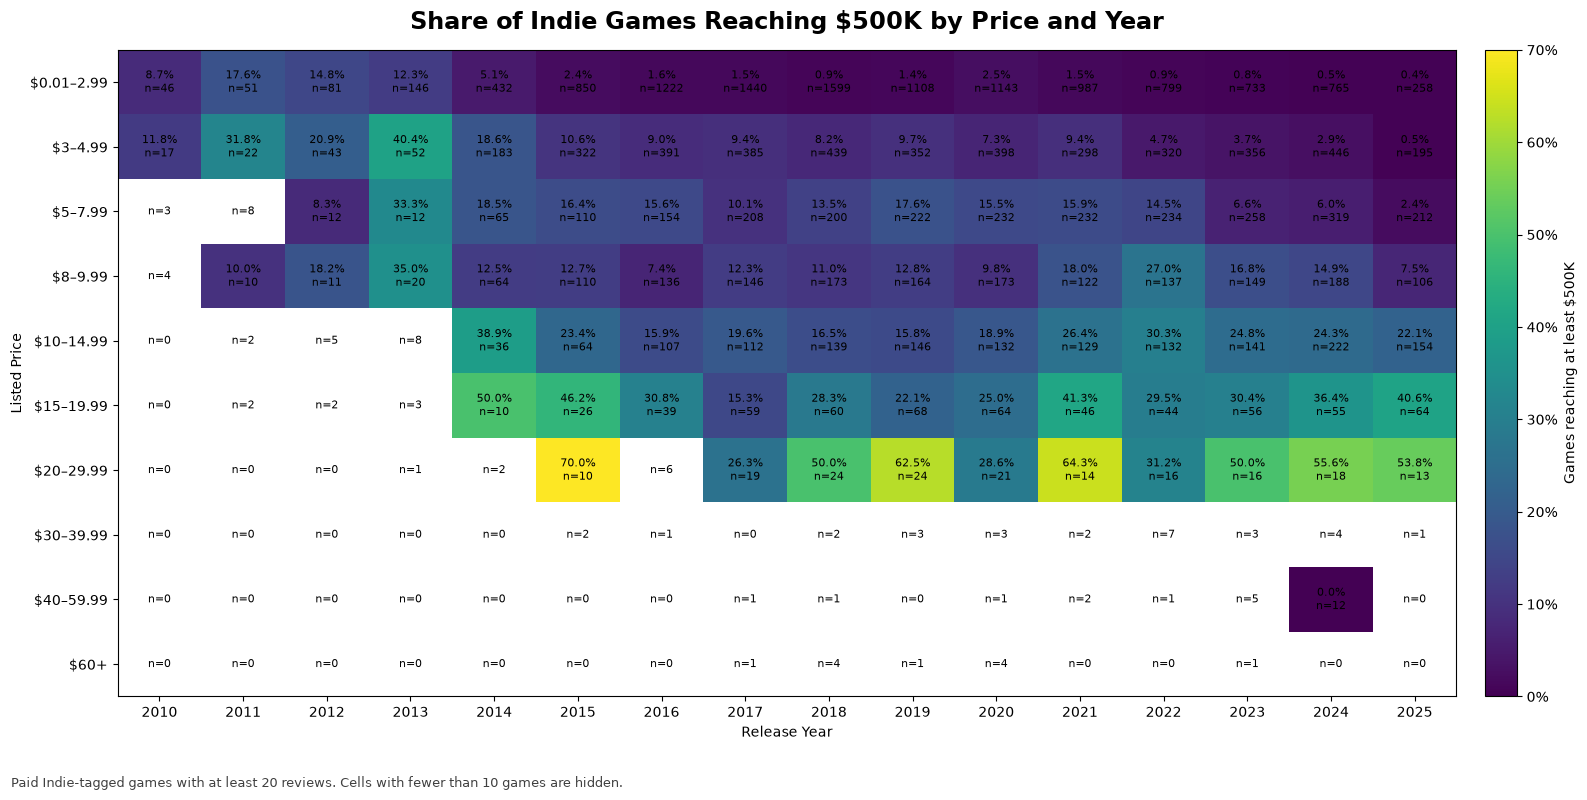

In [27]:
SUCCESS_COLUMN = "success_500k"
SUCCESS_THRESHOLD_LABEL = "$500K"

success_heatmap = (
    price_year_summary
    .pivot(
        index="price_bucket",
        columns="release_year",
        values=SUCCESS_COLUMN
    )
    .reindex(PRICE_LABELS)
)

success_heatmap = success_heatmap.mask(
    games_heatmap < MIN_GAMES_PER_CELL
)

fig, ax = plt.subplots(figsize=(16, 8))

image = ax.imshow(
    success_heatmap.values,
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=np.nanmax(success_heatmap.values)
)

ax.set_xticks(
    range(len(success_heatmap.columns))
)

ax.set_xticklabels(
    success_heatmap.columns
)

ax.set_yticks(
    range(len(success_heatmap.index))
)

ax.set_yticklabels(
    success_heatmap.index
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Listed Price")

ax.set_title(
    (
        "Share of Indie Games Reaching "
        f"{SUCCESS_THRESHOLD_LABEL} by Price and Year"
    ),
    fontsize=17,
    fontweight="bold",
    pad=15
)

for row in range(len(success_heatmap.index)):
    for column in range(
        len(success_heatmap.columns)
    ):
        success_rate = success_heatmap.iloc[
            row,
            column
        ]

        games_count = games_heatmap.iloc[
            row,
            column
        ]

        if pd.isna(success_rate):
            label = (
                "—"
                if pd.isna(games_count)
                else f"n={int(games_count)}"
            )
        else:
            label = (
                f"{success_rate:.1f}%\n"
                f"n={int(games_count)}"
            )

        ax.text(
            column,
            row,
            label,
            ha="center",
            va="center",
            fontsize=8
        )

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.025,
    pad=0.02
)

colorbar.set_label(
    f"Games reaching at least {SUCCESS_THRESHOLD_LABEL}"
)

colorbar.ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:.0f}%"
    )
)

fig.text(
    0.01,
    0.01,
    (
        f"Paid Indie-tagged games with at least {MIN_REVIEWS} reviews. "
        f"Cells with fewer than {MIN_GAMES_PER_CELL} games are hidden."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

In [28]:
# U.S. CPI-U, All Items, annual average
# Base: 1982–84 = 100
#
# 2025 is the published 11-month average because October 2025
# CPI data were unavailable.

CPI_BY_YEAR = {
    2010: 218.056,
    2011: 224.939,
    2012: 229.594,
    2013: 232.957,
    2014: 236.736,
    2015: 237.017,
    2016: 240.007,
    2017: 245.120,
    2018: 251.107,
    2019: 255.657,
    2020: 258.811,
    2021: 270.970,
    2022: 292.655,
    2023: 304.702,
    2024: 313.689,
    2025: 321.943,
}

BASE_YEAR = 2025
BASE_YEAR_CPI = CPI_BY_YEAR[BASE_YEAR]

print(f"Inflation-adjustment base year: {BASE_YEAR}")
print(f"Base-year CPI: {BASE_YEAR_CPI:.3f}")

Inflation-adjustment base year: 2025
Base-year CPI: 321.943


In [29]:
indie_price_real = indie_price_sample.copy()

indie_price_real["annual_cpi"] = (
    indie_price_real["release_year"]
    .map(CPI_BY_YEAR)
)

# Confirm that every included year has a CPI value
missing_cpi_years = (
    indie_price_real.loc[
        indie_price_real["annual_cpi"].isna(),
        "release_year"
    ]
    .dropna()
    .unique()
)

if len(missing_cpi_years) > 0:
    raise ValueError(
        f"Missing CPI values for years: {missing_cpi_years}"
    )

indie_price_real["price_2025_dollars"] = (
    indie_price_real["price"]
    * BASE_YEAR_CPI
    / indie_price_real["annual_cpi"]
)

indie_price_real[
    [
        "name",
        "release_year",
        "price",
        "annual_cpi",
        "price_2025_dollars"
    ]
].head()

,name,release_year,price,annual_cpi,price_2025_dollars
9,MUMBA IV: Egypt Jewels,2021,0.59,270.970,0.700987
11,OMNIMUS,2019,0.99,255.657,1.246684
13,"Forests, Fields and Fortresses",2023,1.49,304.702,1.574309
21,Evertried,2021,5.99,270.970,7.116797
32,Wizard Shrimp,2024,2.99,313.689,3.068675


In [30]:
indie_real_price_by_year = (
    indie_price_real
    .groupby("release_year")
    .agg(
        games=("appid", "nunique"),
        nominal_median_price=("price", "median"),
        real_median_price=(
            "price_2025_dollars",
            "median"
        ),
        nominal_mean_price=("price", "mean"),
        real_mean_price=(
            "price_2025_dollars",
            "mean"
        ),
        real_q25_price=(
            "price_2025_dollars",
            lambda values: values.quantile(0.25)
        ),
        real_q75_price=(
            "price_2025_dollars",
            lambda values: values.quantile(0.75)
        )
    )
    .reset_index()
)

display(
    indie_real_price_by_year.style.format({
        "games": "{:,.0f}",
        "nominal_median_price": "${:,.2f}",
        "real_median_price": "${:,.2f}",
        "nominal_mean_price": "${:,.2f}",
        "real_mean_price": "${:,.2f}",
        "real_q25_price": "${:,.2f}",
        "real_q75_price": "${:,.2f}"
    }).hide(axis="index")
)

release_year,games,nominal_median_price,real_median_price,nominal_mean_price,real_mean_price,real_q25_price,real_q75_price
2010,70,$2.49,$3.68,$3.13,$4.63,$1.83,$7.37
2011,95,$2.99,$4.28,$4.35,$6.23,$2.85,$7.14
2012,154,$2.99,$4.19,$4.26,$5.97,$2.79,$7.00
2013,242,$2.49,$3.44,$3.98,$5.50,$2.06,$6.90
2014,792,$2.99,$4.07,$4.24,$5.76,$1.89,$6.79
2015,"1,494",$2.99,$4.06,$4.22,$5.73,$1.34,$6.78
2016,"2,056",$2.49,$3.34,$4.05,$5.43,$1.33,$6.69
2017,"2,371",$2.39,$3.14,$4.19,$5.50,$1.30,$6.55
2018,"2,641",$2.09,$2.68,$4.44,$5.69,$1.27,$6.40
2019,"2,088",$2.99,$3.77,$5.00,$6.30,$1.25,$8.08


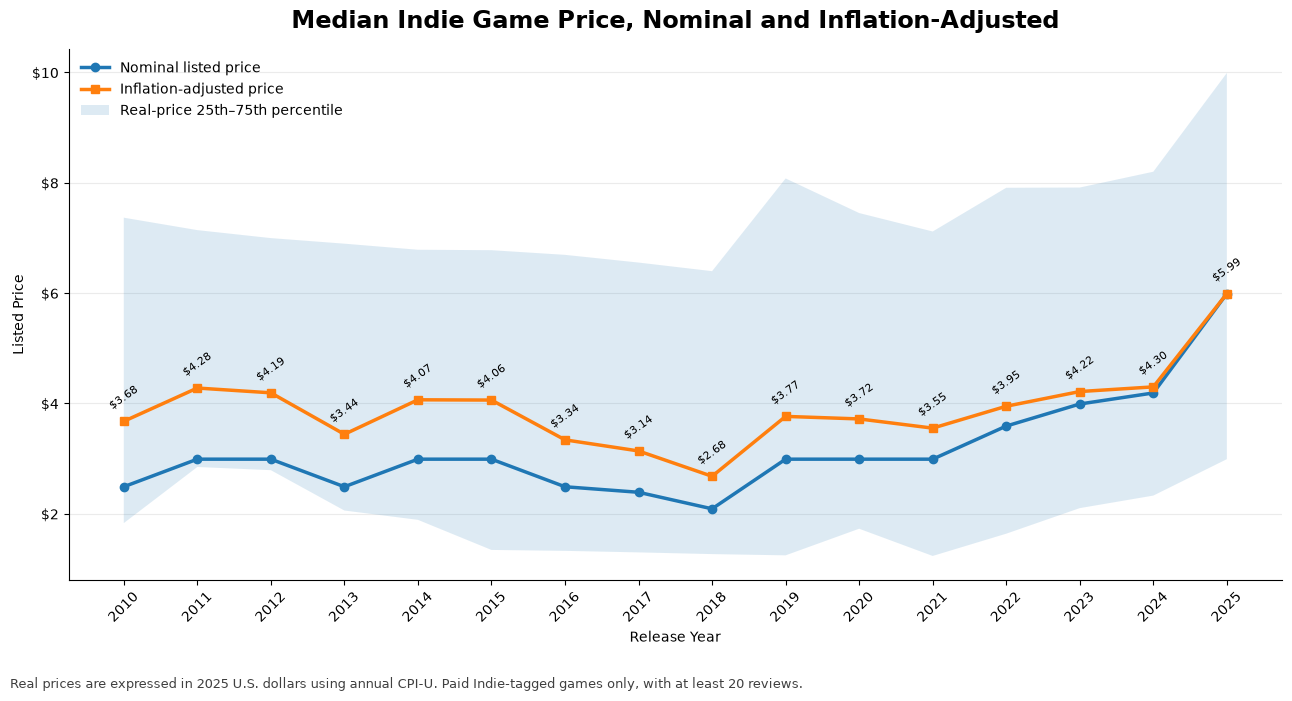

In [31]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plot_data = indie_real_price_by_year.copy()

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(
    plot_data["release_year"],
    plot_data["nominal_median_price"],
    marker="o",
    linewidth=2.5,
    label="Nominal listed price"
)

ax.plot(
    plot_data["release_year"],
    plot_data["real_median_price"],
    marker="s",
    linewidth=2.5,
    label="Inflation-adjusted price"
)

ax.fill_between(
    plot_data["release_year"],
    plot_data["real_q25_price"],
    plot_data["real_q75_price"],
    alpha=0.15,
    label="Real-price 25th–75th percentile"
)

# Label real median values
for _, row in plot_data.iterrows():
    ax.annotate(
        f'${row["real_median_price"]:.2f}',
        xy=(
            row["release_year"],
            row["real_median_price"]
        ),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=35
    )

ax.set_title(
    "Median Indie Game Price, Nominal and Inflation-Adjusted",
    fontsize=17,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Listed Price")

ax.set_xticks(
    plot_data["release_year"]
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value:.0f}"
    )
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.legend(
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        f"Real prices are expressed in {BASE_YEAR} U.S. dollars using "
        "annual CPI-U. Paid Indie-tagged games only, with at least "
        f"{MIN_REVIEWS} reviews."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

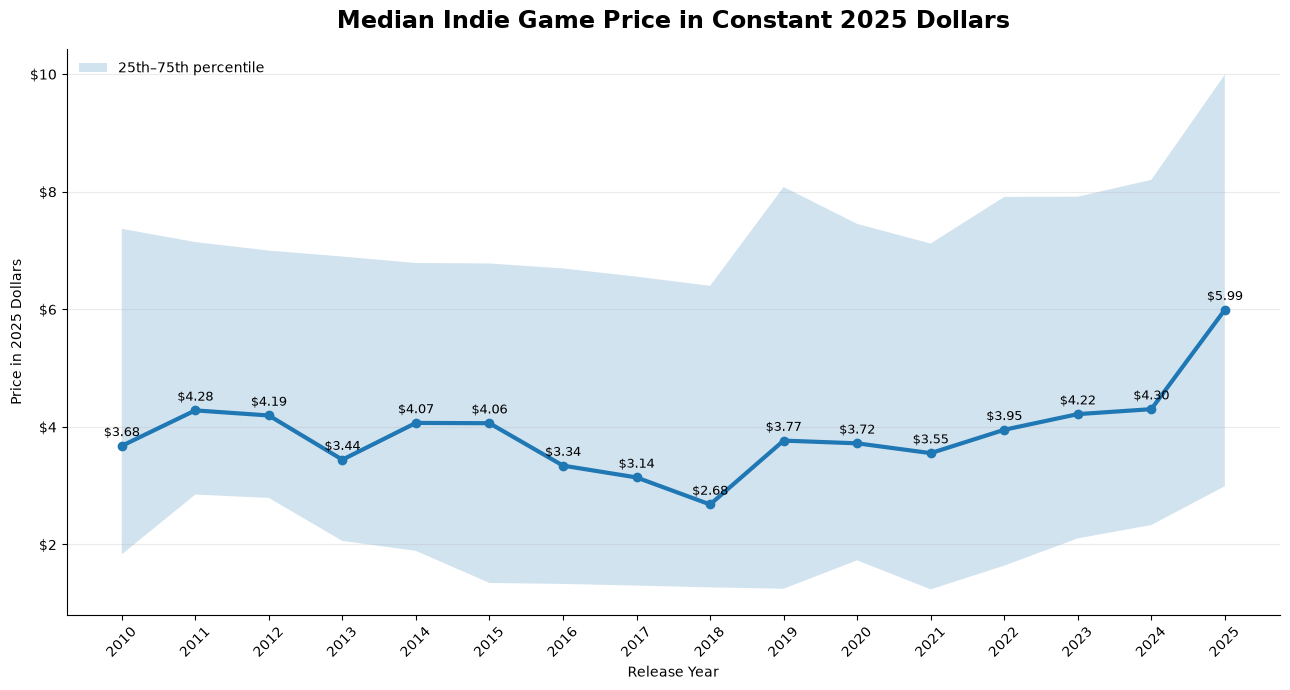

In [32]:
fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(
    plot_data["release_year"],
    plot_data["real_median_price"],
    marker="o",
    linewidth=3
)

ax.fill_between(
    plot_data["release_year"],
    plot_data["real_q25_price"],
    plot_data["real_q75_price"],
    alpha=0.20,
    label="25th–75th percentile"
)

for _, row in plot_data.iterrows():
    ax.annotate(
        f'${row["real_median_price"]:.2f}',
        xy=(
            row["release_year"],
            row["real_median_price"]
        ),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_title(
    f"Median Indie Game Price in Constant {BASE_YEAR} Dollars",
    fontsize=17,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Release Year")
ax.set_ylabel(f"Price in {BASE_YEAR} Dollars")

ax.set_xticks(
    plot_data["release_year"]
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"${value:.0f}"
    )
)

ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [33]:
START_STACK_YEAR = 2020

price_bucket_counts = (
    indie_price_sample.loc[
        indie_price_sample["release_year"] >= START_STACK_YEAR
    ]
    .groupby(
        ["release_year", "price_bucket"],
        observed=False
    )
    .size()
    .unstack(fill_value=0)
    .reindex(columns=PRICE_LABELS)
)

display(price_bucket_counts)

price_bucket,$0.01–2.99,$3–4.99,$5–7.99,$8–9.99,$10–14.99,$15–19.99,$20–29.99,$30–39.99,$40–59.99,$60+
release_year,,,,,,,,,,
2020,1143,398,232,173,132,64,21,3,1,4
2021,987,298,232,122,129,46,14,2,2,0
2022,799,320,234,137,132,44,16,7,1,0
2023,733,356,258,149,141,56,16,3,5,1
2024,765,446,319,188,222,55,18,4,12,0
2025,258,195,212,106,154,64,13,1,0,0


In [34]:
price_bucket_share = (
    price_bucket_counts
    .div(
        price_bucket_counts.sum(axis=1),
        axis=0
    )
    * 100
)

display(price_bucket_share.round(1))

price_bucket,$0.01–2.99,$3–4.99,$5–7.99,$8–9.99,$10–14.99,$15–19.99,$20–29.99,$30–39.99,$40–59.99,$60+
release_year,,,,,,,,,,
2020,52.6,18.3,10.7,8.0,6.1,2.9,1.0,0.1,0.0,0.2
2021,53.9,16.3,12.7,6.7,7.0,2.5,0.8,0.1,0.1,0.0
2022,47.3,18.9,13.8,8.1,7.8,2.6,0.9,0.4,0.1,0.0
2023,42.7,20.7,15.0,8.7,8.2,3.3,0.9,0.2,0.3,0.1
2024,37.7,22.0,15.7,9.3,10.9,2.7,0.9,0.2,0.6,0.0
2025,25.7,19.4,21.1,10.6,15.4,6.4,1.3,0.1,0.0,0.0


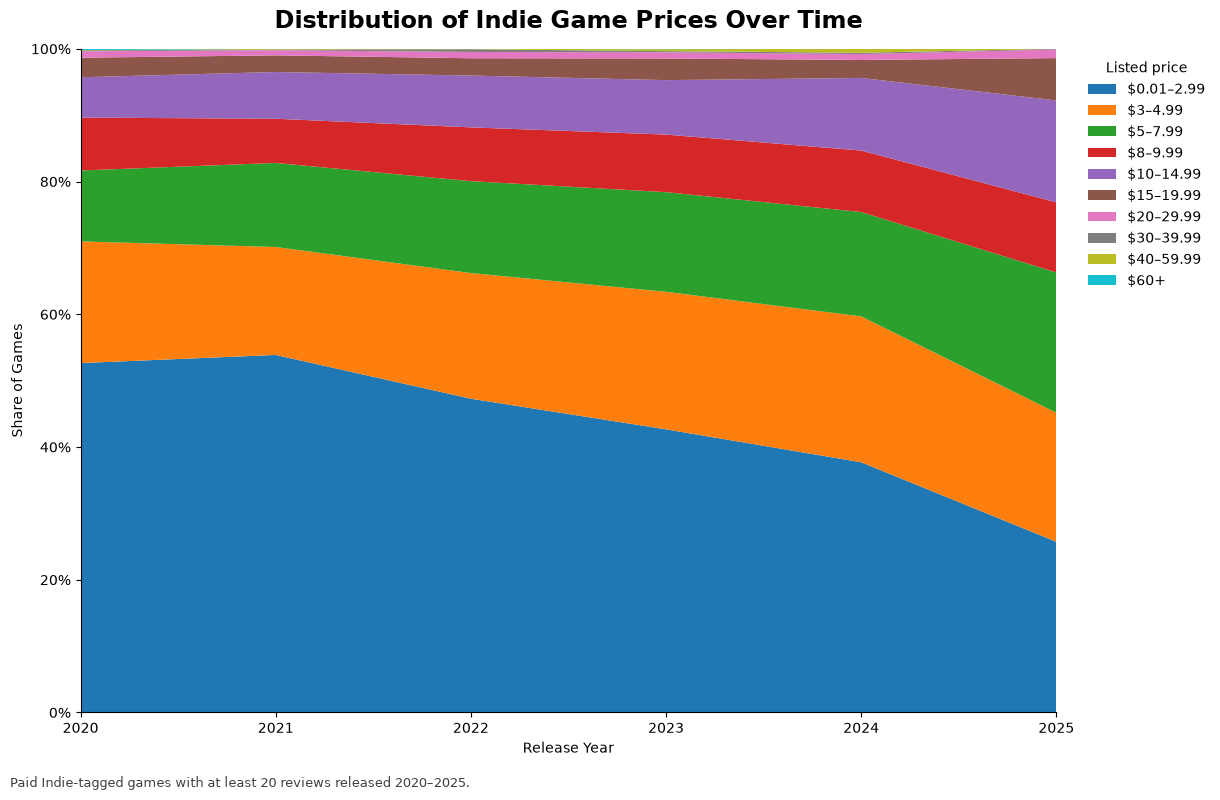

In [35]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.stackplot(
    price_bucket_share.index,
    price_bucket_share.T,
    labels=price_bucket_share.columns
)

ax.set_title(
    "Distribution of Indie Game Prices Over Time",
    fontsize=17,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Share of Games")

ax.set_xlim(
    START_STACK_YEAR,
    END_YEAR
)

ax.set_ylim(0, 100)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:.0f}%"
    )
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Listed price",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

fig.text(
    0.01,
    0.01,
    (
        f"Paid Indie-tagged games with at least {MIN_REVIEWS} reviews "
        f"released {START_STACK_YEAR}–{END_YEAR}."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(rect=[0, 0.03, 0.88, 1])

plt.show()

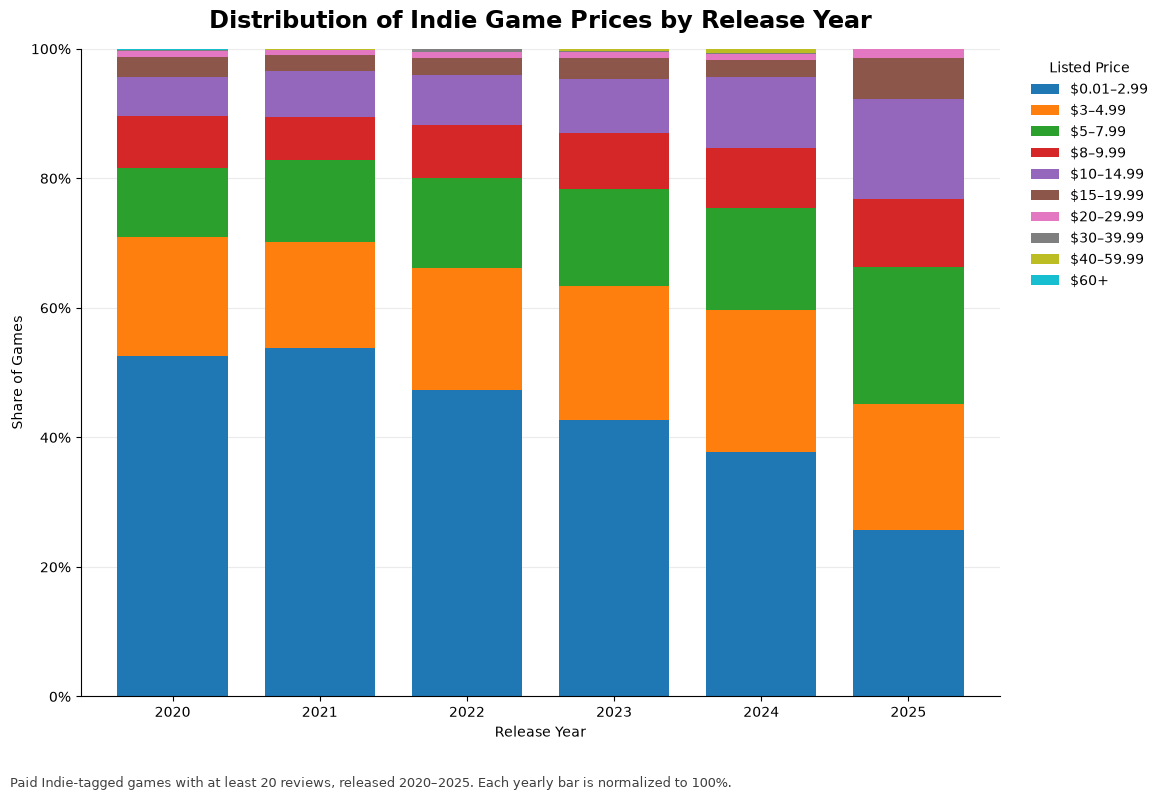

In [36]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

START_STACK_YEAR = 2020

# Count games by year and price bucket
price_bucket_counts = (
    indie_price_sample.loc[
        indie_price_sample["release_year"].between(
            START_STACK_YEAR,
            END_YEAR,
            inclusive="both"
        )
    ]
    .groupby(
        ["release_year", "price_bucket"],
        observed=False
    )
    .size()
    .unstack(fill_value=0)
    .reindex(columns=PRICE_LABELS)
)

# Normalize each year to 100%
price_bucket_share = (
    price_bucket_counts
    .div(
        price_bucket_counts.sum(axis=1),
        axis=0
    )
    * 100
)

# Plot
fig, ax = plt.subplots(figsize=(14, 8))

price_bucket_share.plot(
    kind="bar",
    stacked=True,
    width=0.75,
    ax=ax
)

ax.set_title(
    "Distribution of Indie Game Prices by Release Year",
    fontsize=17,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Share of Games")

ax.set_ylim(0, 100)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:.0f}%"
    )
)

ax.tick_params(
    axis="x",
    rotation=0
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Listed Price",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

fig.text(
    0.01,
    0.01,
    (
        f"Paid Indie-tagged games with at least {MIN_REVIEWS} reviews, "
        f"released {START_STACK_YEAR}–{END_YEAR}. "
        "Each yearly bar is normalized to 100%."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(
    rect=[0, 0.05, 0.84, 1]
)

plt.show()